# Product Demand Segmentation using Clustering

In [5]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (14,6)

# Load Dataset

In [6]:
# ==========================================
# Load Cleaned Dataset
# ==========================================

df = pd.read_csv(r"C:\Users\amans\Downloads\train.csv.zip")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Order Date Function

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [8]:
print(df.shape)

(9800, 18)


# Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [10]:
df["Year"] = df["Order Date"].dt.year

In [11]:
total_sales = (

    df.groupby("Sub-Category")["Sales"]

    .sum()

    .rename("Total Sales")

)

In [12]:
average_order = (

    df.groupby("Sub-Category")["Sales"]

    .mean()

    .rename("Average Order Value")

)

# Monthly Sales Table 

In [13]:
monthly_sales = (

    df.groupby(

        [

            "Sub-Category",

            pd.Grouper(
                key="Order Date",
                freq="M"
            )

        ]

    )["Sales"]

    .sum()

    .reset_index()

)

monthly_sales.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [14]:
sales_volatility = (

    monthly_sales

    .groupby("Sub-Category")["Sales"]

    .std()

    .rename("Sales Volatility")

)

# Yearly Sales Table

In [15]:
yearly_sales = (

    df.groupby(

        [

            "Sub-Category",

            "Year"

        ]

    )["Sales"]

    .sum()

    .reset_index()

)

yearly_sales.head()

,Sub-Category,Year,Sales
0,Accessories,2015,23766.396
1,Accessories,2016,40443.970
2,Accessories,2017,41735.364
3,Accessories,2018,58240.970
4,Appliances,2015,15160.715


# Growth Table

In [16]:
growth = (

    yearly_sales

    .pivot(

        index="Sub-Category",

        columns="Year",

        values="Sales"

    )

)

growth = growth.fillna(0)

growth.head()

Year,2015,2016,2017,2018
Sub-Category,,,,
Accessories,23766.3960,40443.9700,41735.3640,58240.9700
Appliances,15160.7150,23228.1790,26016.7870,40212.7220
Art,5897.5340,6091.6360,5890.6080,8825.6320
Binders,43263.2670,36049.7460,48994.5170,71721.2550
Bookcases,20036.6776,37476.7749,26275.4665,30024.2797


In [17]:
growth["Sales Growth Rate"] = (

    growth.iloc[:,-1] -

    growth.iloc[:,0]

) / growth.iloc[:,0] * 100

growth["Sales Growth Rate"] = growth[
    "Sales Growth Rate"
].replace(

    [np.inf,-np.inf],

    0

)

growth["Sales Growth Rate"] = growth[
    "Sales Growth Rate"
].fillna(0)

# Feature Scaling

In [18]:
features = pd.concat(

    [

        total_sales,

        average_order,

        sales_volatility,

        growth["Sales Growth Rate"]

    ],

    axis=1

)

features

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961
Appliances,104618.4030,227.926804,1821.621539,165.242912
Art,26705.4100,34.019631,330.488343,49.649531
Binders,200028.7850,134.067550,3848.223648,65.778638
Bookcases,113813.1987,503.598224,2220.405080,49.846598
Chairs,322822.7310,531.833165,4407.232960,20.954677
Copiers,146248.0940,2215.880212,5500.774391,479.729510
Envelopes,16128.0460,65.032444,228.218688,-12.121345
Fasteners,3001.9600,14.027850,48.742229,30.468364


In [19]:
features = features.fillna(0)

# Feature Describe

In [20]:
features.describe()

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
count,17.000000,17.000000,17.000000,17.000000
mean,133031.575453,430.173042,2430.679393,77.522930
std,101630.985892,603.908538,1808.905841,115.410999
min,3001.960000,14.027850,48.742229,-29.793120
25%,46420.308000,65.032444,1024.824982,30.468364
50%,113813.198700,227.926804,2220.405080,38.366108
75%,200028.785000,503.598224,3848.223648,91.901971
max,327782.448000,2215.880212,5603.554747,479.729510


# Standard Scaler

In [21]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features = pd.DataFrame(

    scaled_features,

    columns=features.columns,

    index=features.index

)

scaled_features.head()

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
Sub-Category,,,,
Accessories,0.315986,-0.363549,0.085085,0.603161
Appliances,-0.288176,-0.345202,-0.347062,0.783458
Art,-1.078397,-0.676171,-1.196761,-0.248947
Binders,0.679509,-0.505405,0.807765,-0.104892
Bookcases,-0.194919,0.125325,-0.119821,-0.247187


In [22]:
scaled_features.describe().round(2)

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
count,17.00,17.00,17.00,17.00
mean,-0.00,-0.00,-0.00,0.00
std,1.03,1.03,1.03,1.03
min,-1.32,-0.71,-1.36,-0.96
25%,-0.88,-0.62,-0.80,-0.42
50%,-0.19,-0.35,-0.12,-0.35
75%,0.68,0.13,0.81,0.13
max,1.98,3.05,1.81,3.59


In [23]:
features.to_csv(

    "product_segmentation_features.csv"

)

scaled_features.to_csv(

    "scaled_product_features.csv"

)

print("Feature datasets saved successfully.")

Feature datasets saved successfully.


# WCSS Value

In [24]:
# ==========================================
# Notebook 6 - Part 2
# Section A - Elbow Method
# ==========================================

from sklearn.cluster import KMeans

# WCSS (Within Cluster Sum of Squares)
wcss = []

# Calculate WCSS for K = 1 to 10
for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

print("WCSS Values")
for i, value in enumerate(wcss, start=1):
    print(f"K = {i} : {value:.2f}")

WCSS Values
K = 1 : 68.00
K = 2 : 38.52
K = 3 : 16.60
K = 4 : 10.57
K = 5 : 6.08
K = 6 : 3.88
K = 7 : 2.57
K = 8 : 1.66
K = 9 : 1.25
K = 10 : 0.86


# Elbow Method

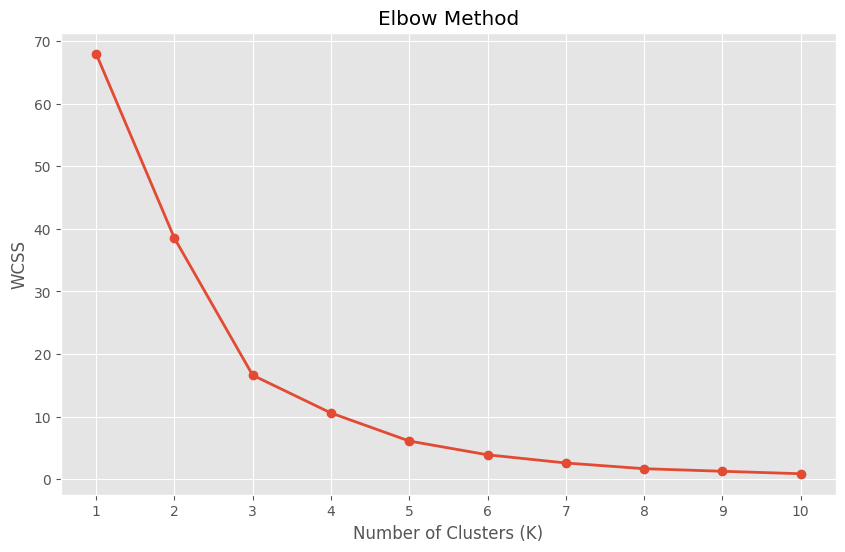

In [25]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.xticks(range(1,11))

plt.grid(True)

plt.show()

In [26]:
optimal_clusters = 4

print(f"Optimal Number of Clusters : {optimal_clusters}")

Optimal Number of Clusters : 4


In [27]:
# ==========================================
# Import KMeans
# ==========================================

from sklearn.cluster import KMeans

In [28]:
# ==========================================
# Train K-Means Model
# ==========================================

kmeans = KMeans(
    n_clusters=optimal_clusters,
    init="k-means++",
    random_state=42,
    n_init=10
)

kmeans.fit(scaled_features)

print("K-Means model trained successfully.")

K-Means model trained successfully.


# Cluster Labels

In [29]:
# Predict cluster for each Sub-Category

cluster_labels = kmeans.predict(scaled_features)

cluster_labels

array([0, 2, 2, 0, 2, 0, 1, 2, 2, 2, 2, 3, 2, 0, 0, 2, 0])

# Add Cluster Column

In [30]:
# Add Cluster Column

features["Cluster"] = cluster_labels

features.head()

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,2579.994809,145.055961,0
Appliances,104618.4030,227.926804,1821.621539,165.242912,2
Art,26705.4100,34.019631,330.488343,49.649531,2
Binders,200028.7850,134.067550,3848.223648,65.778638,0
Bookcases,113813.1987,503.598224,2220.405080,49.846598,2


# cluster assignment

In [31]:
cluster_assignment = features.reset_index()

cluster_assignment

,Sub-Category,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate,Cluster
0,Accessories,164186.7000,217.178175,2579.994809,145.055961,0
1,Appliances,104618.4030,227.926804,1821.621539,165.242912,2
2,Art,26705.4100,34.019631,330.488343,49.649531,2
3,Binders,200028.7850,134.067550,3848.223648,65.778638,0
4,Bookcases,113813.1987,503.598224,2220.405080,49.846598,2
5,Chairs,322822.7310,531.833165,4407.232960,20.954677,0
6,Copiers,146248.0940,2215.880212,5500.774391,479.729510,1
7,Envelopes,16128.0460,65.032444,228.218688,-12.121345,2
8,Fasteners,3001.9600,14.027850,48.742229,30.468364,2
9,Furnishings,89212.0180,95.823865,1360.017867,106.824969,2


# cluster count

In [32]:
cluster_counts = cluster_assignment["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    6
1    1
2    9
3    1
Name: count, dtype: int64


# cluster summary

In [33]:
cluster_summary = (

    cluster_assignment

    .groupby("Cluster")

    .agg({

        "Total Sales":"mean",

        "Average Order Value":"mean",

        "Sales Volatility":"mean",

        "Sales Growth Rate":"mean"

    })

)

cluster_summary = cluster_summary.round(2)

cluster_summary

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
Cluster,,,,
0,239495.78,361.13,3489.06,56.47
1,146248.09,2215.88,5500.77,479.73
2,54341.71,142.75,1031.43,58.80
3,189238.63,1645.55,5603.55,-29.79


In [34]:
cluster_assignment.to_csv(

    "product_clusters.csv",

    index=False

)

cluster_summary.to_csv(

    "cluster_summary.csv"

)

print("Cluster files saved successfully.")

Cluster files saved successfully.


# No of Product in Each Cluster

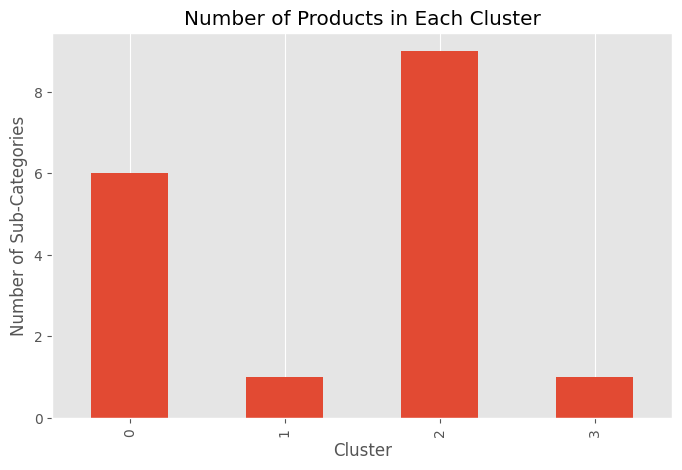

In [35]:
plt.figure(figsize=(8,5))

cluster_counts.sort_index().plot(

    kind="bar"

)

plt.title("Number of Products in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Sub-Categories")

plt.grid(axis="y")

plt.show()

# Product assigned to Each Cluster

In [36]:
# ==========================================
# Products Assigned to Each Cluster
# ==========================================

for cluster in sorted(cluster_assignment["Cluster"].unique()):

    print("=" * 50)
    print(f"Cluster {cluster}")

    products = cluster_assignment[
        cluster_assignment["Cluster"] == cluster
    ]["Sub-Category"].tolist()

    print(products)

Cluster 0
['Accessories', 'Binders', 'Chairs', 'Phones', 'Storage', 'Tables']
Cluster 1
['Copiers']
Cluster 2
['Appliances', 'Art', 'Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Paper', 'Supplies']
Cluster 3
['Machines']


# cluster size table

In [37]:
cluster_size = (

    cluster_assignment

    .groupby("Cluster")

    .size()

    .reset_index(name="Number of Products")

)

cluster_size

,Cluster,Number of Products
0,0,6
1,1,1
2,2,9
3,3,1


# cluster profile

In [38]:
cluster_profile = (

    cluster_assignment

    .groupby("Cluster")[

        [

            "Total Sales",

            "Average Order Value",

            "Sales Volatility",

            "Sales Growth Rate"

        ]

    ]

    .mean()

)

cluster_profile = cluster_profile.round(2)

cluster_profile

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
Cluster,,,,
0,239495.78,361.13,3489.06,56.47
1,146248.09,2215.88,5500.77,479.73
2,54341.71,142.75,1031.43,58.80
3,189238.63,1645.55,5603.55,-29.79


# Average Feature Values by Cluster

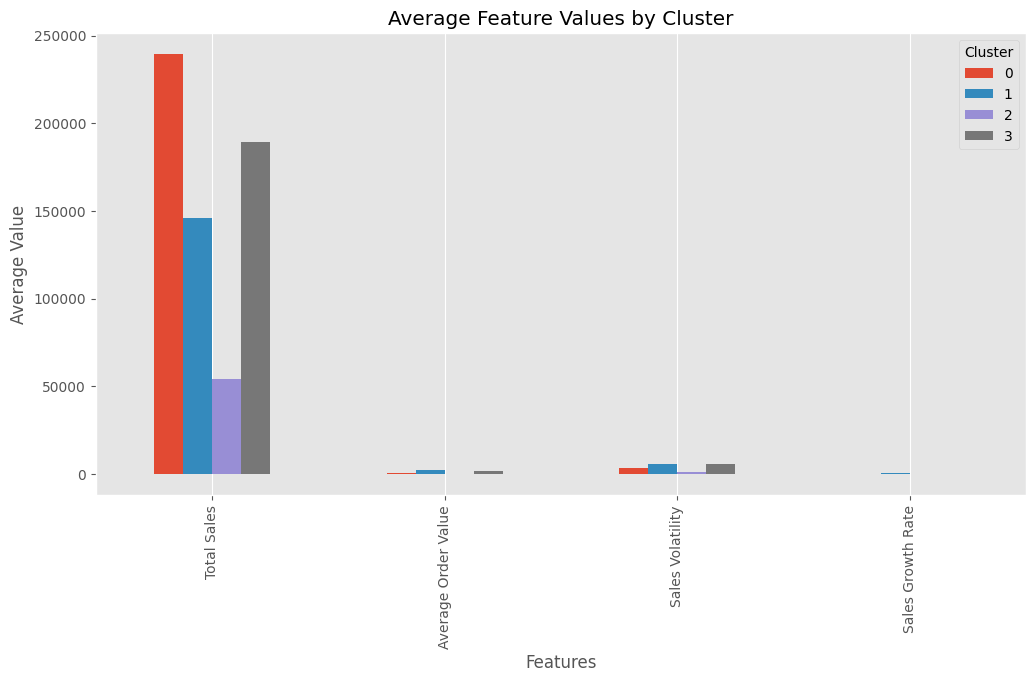

In [39]:
cluster_profile.T.plot(

    kind="bar",

    figsize=(12,6)

)

plt.title("Average Feature Values by Cluster")

plt.xlabel("Features")

plt.ylabel("Average Value")

plt.grid(axis="y")

plt.legend(title="Cluster")

plt.show()

In [ ]:
# center df

In [40]:
centers_df = pd.DataFrame(

    kmeans.cluster_centers_,

    columns=scaled_features.columns

)

centers_df.index.name = "Cluster"

centers_df

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate
Cluster,,,,
0,1.079797,-0.117843,0.603099,-0.188074
1,0.134046,3.047920,1.749445,3.592249
2,-0.798100,-0.490591,-0.797339,-0.167258
3,0.570071,2.074462,1.808013,-0.958478


In [41]:
cluster_profile.to_csv(

    "cluster_profile.csv"

)

cluster_size.to_csv(

    "cluster_size.csv",

    index=False

)

print("Cluster profile saved successfully.")

Cluster profile saved successfully.


In [42]:
highest_sales_cluster = (

    cluster_profile["Total Sales"]

    .idxmax()

)

print(

    "Highest Sales Cluster :",

    highest_sales_cluster

)

Highest Sales Cluster : 0


In [43]:
highest_growth_cluster = (

    cluster_profile["Sales Growth Rate"]

    .idxmax()

)

print(

    "Highest Growth Cluster :",

    highest_growth_cluster

)

Highest Growth Cluster : 1


In [44]:
cluster_overview = cluster_profile.copy()

cluster_overview["Number of Products"] = (

    cluster_size

    .set_index("Cluster")["Number of Products"]

)

cluster_overview

,Total Sales,Average Order Value,Sales Volatility,Sales Growth Rate,Number of Products
Cluster,,,,,
0,239495.78,361.13,3489.06,56.47,6
1,146248.09,2215.88,5500.77,479.73,1
2,54341.71,142.75,1031.43,58.80,9
3,189238.63,1645.55,5603.55,-29.79,1


In [45]:
cluster_overview.to_csv(

    "cluster_overview.csv"

)

print("Cluster overview exported successfully.")

Cluster overview exported successfully.
